# 04 · Réglage des hyperparamètres et contrôle du sur-apprentissage

**Question : comment régler LightGBM sans sur-apprendre ?**

Stratégie :

1. **validation croisée temporelle** (`TimeSeriesSplit`) : chaque pli entraîne sur le passé et valide sur les 2 mois suivants ;
2. les 6 plis couvrent **une année complète** : chaque saison pèse dans le choix ;
3. une **petite grille** sur les paramètres qui contrôlent la complexité (`num_leaves`, `min_child_samples`), avec **le même taux d'apprentissage** que l'entraînement final ;
4. **early stopping** pour choisir le nombre d'arbres ;
5. chaque essai est **enregistré dans MLflow** (expérience `conso_energie_tuning`) ;
6. les paramètres retenus sont reportés dans `params.yaml`, puis la CI réentraîne et la promotion champion / challenger décide.

> **Leçon d'une première version.** Le premier protocole utilisait 4 plis de 60 jours (tous en automne-hiver) et un taux d'apprentissage de 0.1 pour aller plus vite. Il avait retenu `num_leaves=15, min_child_samples=100`. Les modèles entraînés ainsi (v2, v3) ont été **refusés par la promotion automatique** : moins bons que la v1 sur le test estival. En isolant chaque facteur (données vs paramètres), la cause était le réglage : validé sur l'hiver seulement, avec un taux d'apprentissage différent du modèle final. Le protocole ci-dessous corrige ces deux points, sans jamais regarder le jeu de test pour choisir.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

import itertools

import mlflow
from lightgbm import early_stopping
from sklearn.model_selection import TimeSeriesSplit

from src.config import TUNING_EXPERIMENT, configure_mlflow, load_params
from src.data import load_dataset, temporal_split
from src.features import FEATURE_COLUMNS
from src.models import lightgbm, score

params = load_params()
fit, validation, test = temporal_split(load_dataset(), params["split"])
X, y = FEATURE_COLUMNS, "consommation_mw"

# 4 dernières années du train ; la dernière année sert de validation, découpée en 6 plis de 2 mois.
tuning_data = fit[fit["timestamp"] >= fit["timestamp"].max() - pd.DateOffset(years=4)].reset_index(drop=True)
folds = list(TimeSeriesSplit(n_splits=6, test_size=48 * 61).split(tuning_data))
fold_names = [f"{tuning_data['timestamp'].iloc[v[0]]:%m/%y}→{tuning_data['timestamp'].iloc[v[-1]]:%m/%y}" for _, v in folds]
print(f"{len(tuning_data):,} lignes · plis de validation :", ", ".join(fold_names))

70,097 lignes · plis de validation : 05/25→07/25, 07/25→09/25, 09/25→11/25, 11/25→01/26, 01/26→03/26, 03/26→05/26


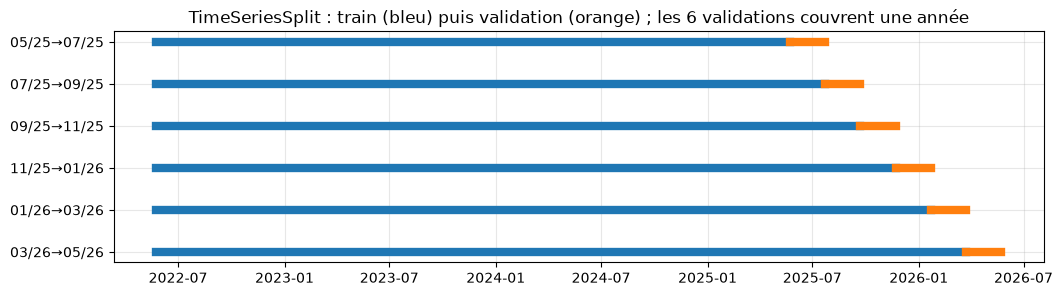

In [2]:
fig, ax = plt.subplots(figsize=(12, 3))
dates = tuning_data["timestamp"]
for index, (train_index, valid_index) in enumerate(folds):
    ax.plot([dates.iloc[train_index[0]], dates.iloc[train_index[-1]]], [index, index], color="tab:blue", linewidth=6)
    ax.plot([dates.iloc[valid_index[0]], dates.iloc[valid_index[-1]]], [index, index], color="tab:orange", linewidth=6)
ax.set(title="TimeSeriesSplit : train (bleu) puis validation (orange) ; les 6 validations couvrent une année", yticks=range(len(folds)), yticklabels=fold_names)
ax.invert_yaxis();

## Grille de recherche avec validation croisée temporelle

In [3]:
grid = {"num_leaves": [15, 31, 63, 127], "min_child_samples": [20, 100]}
base = params["lightgbm"]  # même taux d'apprentissage que l'entraînement final


def cross_validate(candidate: dict) -> list[dict]:
    scores = []
    for fold_name, (train_index, valid_index) in zip(fold_names, folds, strict=True):
        train, valid = tuning_data.iloc[train_index], tuning_data.iloc[valid_index]
        model = lightgbm(candidate).fit(
            train[X], train[y], eval_X=valid[X], eval_y=valid[y], eval_metric="rmse",
            callbacks=[early_stopping(candidate["early_stopping_rounds"], verbose=False)],
        )
        scores.append({"pli": fold_name, "train_rmse": score(train[y], model.predict(train[X]))["rmse"],
                       "cv_rmse": score(valid[y], model.predict(valid[X]))["rmse"], "trees": model.best_iteration_})
    return scores


configure_mlflow(TUNING_EXPERIMENT)
rows = []
with mlflow.start_run(run_name=f"grille num_leaves x min_child_samples · 6 plis sur 1 an · {pd.Timestamp.now():%d/%m}") as tuning_run:
    mlflow.set_tag("stage", "tuning")
    for num_leaves, min_child_samples in itertools.product(grid["num_leaves"], grid["min_child_samples"]):
        candidate = {**base, "num_leaves": num_leaves, "min_child_samples": min_child_samples}
        scores = pd.DataFrame(cross_validate(candidate))
        metrics = {"cv_rmse": scores["cv_rmse"].mean(), "cv_rmse_std": scores["cv_rmse"].std(),
                   "train_rmse": scores["train_rmse"].mean(), "trees": scores["trees"].mean()}
        with mlflow.start_run(run_name=f"leaves={num_leaves}_child={min_child_samples}", nested=True):
            mlflow.log_params(candidate)
            mlflow.log_metrics(metrics)
        rows += [{"num_leaves": num_leaves, "min_child_samples": min_child_samples, **row} for row in scores.to_dict("records")]

per_fold = pd.DataFrame(rows)
results = (per_fold.groupby(["num_leaves", "min_child_samples"])
           .agg(cv_rmse=("cv_rmse", "mean"), cv_rmse_std=("cv_rmse", "std"), train_rmse=("train_rmse", "mean"), trees=("trees", "mean"))
           .reset_index().sort_values("cv_rmse"))
best = results.iloc[0]
mlflow.MlflowClient().set_tag(tuning_run.info.run_id, "mlflow.note.content",
    f"Validation croisée temporelle : 6 plis de 2 mois couvrant une année ({fold_names[0]} … {fold_names[-1]}), learning_rate={base['learning_rate']}. "
    f"Meilleure combinaison : num_leaves={best['num_leaves']:.0f}, min_child_samples={best['min_child_samples']:.0f} "
    f"(CV RMSE {best['cv_rmse']:.0f} ± {best['cv_rmse_std']:.0f} MW).")
results.round(0)

,num_leaves,min_child_samples,cv_rmse,cv_rmse_std,train_rmse,trees
7,127,100,1947.0,890.0,1243.0,254.0
5,63,100,1966.0,904.0,1266.0,346.0
0,15,20,1967.0,848.0,1525.0,463.0
6,127,20,1969.0,919.0,1057.0,201.0
4,63,20,1971.0,927.0,1210.0,279.0
2,31,20,1972.0,909.0,1340.0,406.0
3,31,100,1975.0,919.0,1423.0,435.0
1,15,100,1978.0,877.0,1597.0,541.0


## Erreur par pli : un réglage gagne-t-il partout, ou seulement sur une saison ?

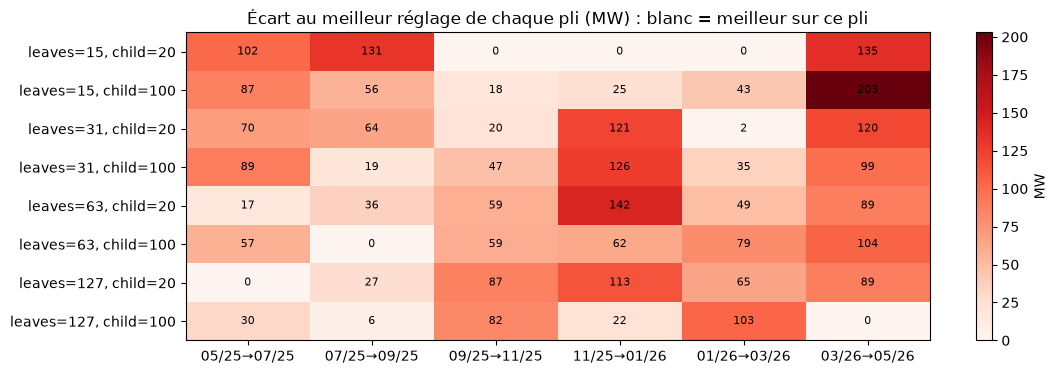

In [4]:
table = per_fold.pivot_table(index=["num_leaves", "min_child_samples"], columns="pli", values="cv_rmse")[fold_names]
gap = table.sub(table.min())
fig, ax = plt.subplots(figsize=(12, 4))
image = ax.imshow(gap, aspect="auto", cmap="Reds")
ax.set(xticks=range(len(fold_names)), xticklabels=fold_names, yticks=range(len(table)), yticklabels=[f"leaves={a}, child={b}" for a, b in table.index],
       title="Écart au meilleur réglage de chaque pli (MW) : blanc = meilleur sur ce pli")
for i in range(len(table)):
    for j in range(len(fold_names)):
        ax.text(j, i, f"{gap.iloc[i, j]:.0f}", ha="center", va="center", fontsize=8)
ax.grid(False)
fig.colorbar(image, ax=ax, label="MW");

Chaque colonne est une période de 2 mois. Un réglage qui ne serait bon que l'hiver apparaîtrait blanc sur les colonnes d'hiver et rouge l'été : c'est exactement ce que le premier protocole (plis d'automne-hiver uniquement) ne pouvait pas voir. On compare les réglages **pli par pli** (même période, même difficulté) plutôt qu'avec les seuls écarts-types, dominés par la différence hiver / été.

**Ici**, les réglages à 15 feuilles sont les meilleurs de septembre à mars mais nettement moins bons au printemps et en été : c'est pourquoi le premier protocole, validé sur l'automne-hiver, les avait retenus à tort.

Meilleur réglage : num_leaves=127, min_child_samples=100 (CV RMSE 1947 MW, train 1243 MW)


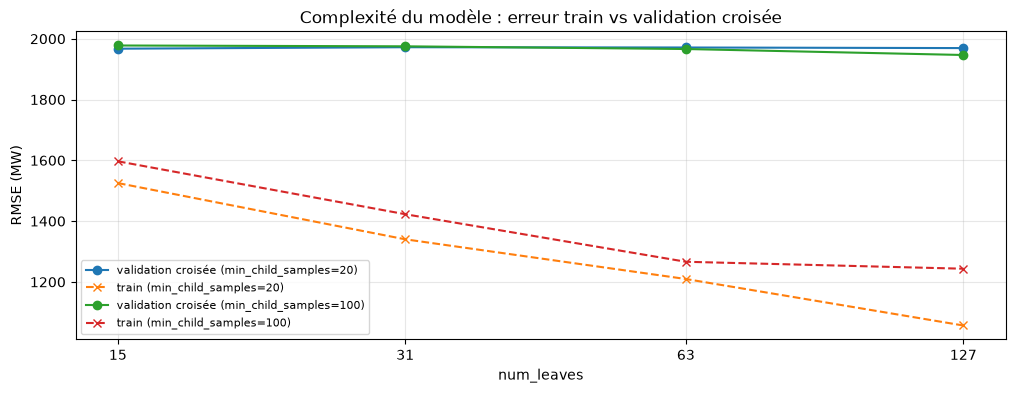

In [5]:
fig, ax = plt.subplots()
for min_child_samples, group in results.sort_values("num_leaves").groupby("min_child_samples"):
    ax.plot(group["num_leaves"], group["cv_rmse"], marker="o", label=f"validation croisée (min_child_samples={min_child_samples})")
    ax.plot(group["num_leaves"], group["train_rmse"], marker="x", linestyle="--", label=f"train (min_child_samples={min_child_samples})")
ax.set(xscale="log", xticks=grid["num_leaves"], xticklabels=grid["num_leaves"], title="Complexité du modèle : erreur train vs validation croisée", xlabel="num_leaves", ylabel="RMSE (MW)")
ax.minorticks_off()
ax.legend(fontsize=8)

print(f"Meilleur réglage : num_leaves={best['num_leaves']:.0f}, min_child_samples={best['min_child_samples']:.0f} "
      f"(CV RMSE {best['cv_rmse']:.0f} MW, train {best['train_rmse']:.0f} MW)")

**Lecture (compromis biais / variance) :**

- l'erreur **train** baisse toujours quand le modèle se complexifie ;
- l'erreur de **validation croisée** baisse tant que la complexité aide à généraliser, puis stagne ou remonte ;
- l'**écart train / validation** qui grandit est la signature du sur-apprentissage ;
- on retient la combinaison de **meilleure erreur moyenne sur l'année**, en vérifiant sur la carte par pli qu'elle ne gagne pas sur une seule saison.

## Early stopping : combien d'arbres ?

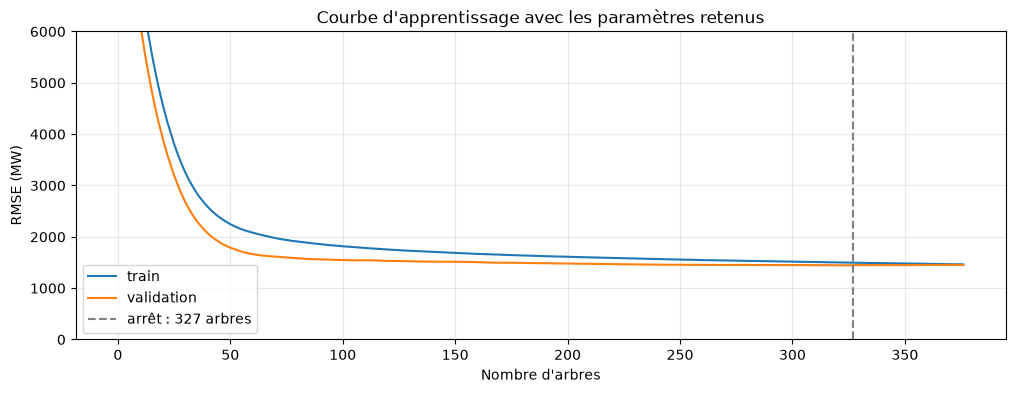

In [6]:
chosen = {**params["lightgbm"], "num_leaves": int(best["num_leaves"]), "min_child_samples": int(best["min_child_samples"])}
model = lightgbm(chosen).fit(
    fit[X], fit[y], eval_X=(fit[X], validation[X]), eval_y=(fit[y], validation[y]),
    eval_names=["train", "validation"], eval_metric="rmse",
    callbacks=[early_stopping(chosen["early_stopping_rounds"], verbose=False)],
)
fig, ax = plt.subplots()
for name, curve in model.evals_result_.items():
    ax.plot(curve["rmse"], label=name)
ax.axvline(model.best_iteration_, color="grey", linestyle="--", label=f"arrêt : {model.best_iteration_} arbres")
ax.set(title="Courbe d'apprentissage avec les paramètres retenus", xlabel="Nombre d'arbres", ylabel="RMSE (MW)", ylim=(0, 6000))
ax.legend();

L'early stopping arrête l'ajout d'arbres quand l'erreur de validation ne s'améliore plus pendant 50 itérations : au-delà, on ne réduirait plus que l'erreur d'entraînement.

*Pourquoi la validation est-elle sous le train ?* La RMSE est en MW : la période de validation (printemps) a une consommation plus basse, donc des erreurs absolues plus faibles que le train, qui contient tous les hivers. Pour juger le sur-apprentissage, on compare des erreurs **sur des périodes comparables** : c'est ce que fait la validation croisée pli par pli ci-dessus.

In [7]:
print("Paramètres retenus à reporter dans params.yaml :")
{key: chosen[key] for key in ["learning_rate", "num_leaves", "min_child_samples", "colsample_bytree", "reg_lambda"]}

Paramètres retenus à reporter dans params.yaml :


{'learning_rate': 0.05,
 'num_leaves': 127,
 'min_child_samples': 100,
 'colsample_bytree': 0.9,
 'reg_lambda': 0.0}